# Project Introduction

## Objective

Understand audience behavior in the Microsoft MIND dataset and identify characteristics that inform recommendation system design.

## Key Findings

- The MIND dataset contains **51,282 news articles** across **16 content categories**.
- News and Sports dominate the catalog, indicating a long-tail distribution across categories.
- Reader histories vary substantially, suggesting that user personalization could improve engagement.
- Impression logs provide both positive (clicked) and implicit negative (not clicked) feedback, enabling learning-to-rank approaches.
- The category imbalance suggests that popularity-based recommenders may over-recommend dominant topics, motivating the evaluation of diversity-aware recommendation methods.

What does this dataset look like?

Dataset Overview

- News articles
- User interactions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import MINDDataLoader

loader = MINDDataLoader(PROJECT_ROOT / "data" / "raw" / "MINDsmall")

news, behaviors = loader.load()

print(news.shape)
print(behaviors.shape)

(51282, 8)
(156965, 5)


In [3]:
print("=" * 60)
print("MIND DATASET OVERVIEW")
print("=" * 60)

print(f"News articles      : {len(news):,}")
print(f"User sessions      : {len(behaviors):,}")
print(f"Unique users       : {behaviors.user_id.nunique():,}")
print(f"Categories         : {news.category.nunique()}")
print(f"Subcategories      : {news.subcategory.nunique()}")

MIND DATASET OVERVIEW
News articles      : 51,282
User sessions      : 156,965
Unique users       : 50,000
Categories         : 17
Subcategories      : 264


Content Analysis
   - Category distribution
   - Subcategory trends

In [4]:
category_counts = (
    news["category"]
    .value_counts()
    .sort_values(ascending=False)
)

category_counts

category
news             15774
sports           14510
finance           3107
foodanddrink      2551
lifestyle         2479
travel            2350
video             2068
weather           2048
health            1885
autos             1639
tv                 889
music              769
movies             606
entertainment      587
kids                17
middleeast           2
northamerica         1
Name: count, dtype: int64

Chart

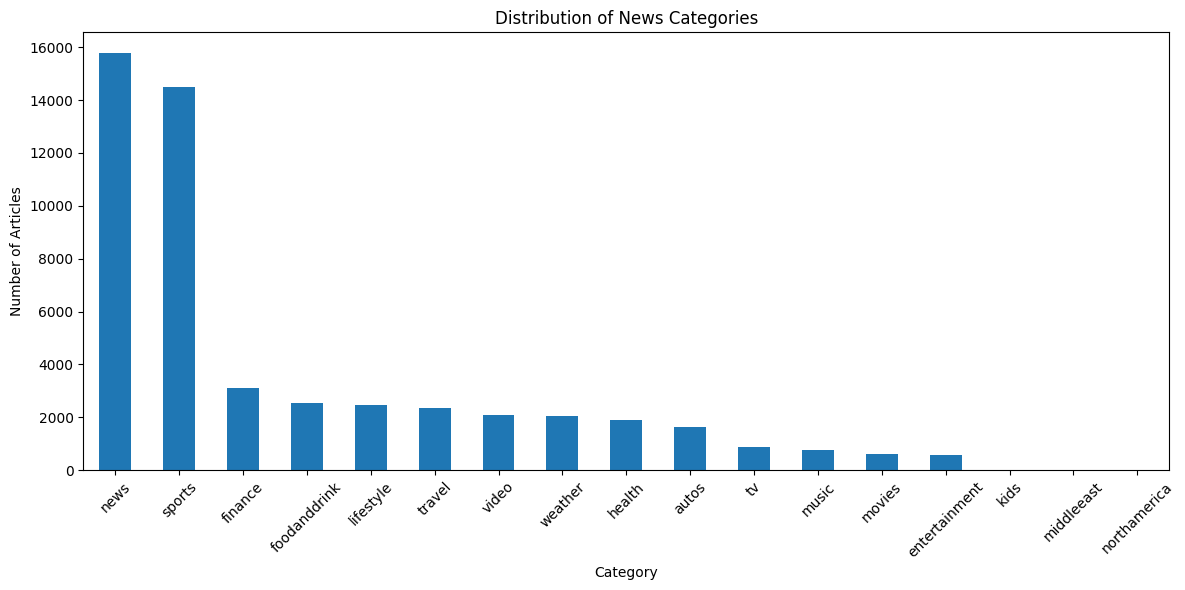

In [5]:
plt.figure(figsize=(12,6))

category_counts.plot(kind="bar")

plt.title("Distribution of News Categories")

plt.xlabel("Category")

plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Top Subcategories

In [6]:
news["subcategory"].value_counts().head(20)

subcategory
newsus                      6564
football_nfl                5420
newspolitics                2826
newscrime                   2254
weathertopstories           2047
newsworld                   1720
football_ncaa               1665
baseball_mlb                1661
basketball_nba              1555
newsscienceandtechnology    1210
news                        1185
newstrends                  1176
more_sports                 1065
travelarticle               1042
travelnews                   902
lifestylebuzz                894
autosnews                    837
basketball_ncaa              774
financenews                  697
finance-real-estate          584
Name: count, dtype: int64

Audience Analysis
   - User activity
   - Reading history length
   - Impression behavior

In [7]:
behaviors["history_length"] = (
    behaviors["history"]
    .fillna("")
    .apply(lambda x: len(x.split()) if x else 0)
)

In [8]:
behaviors["history_length"].describe()

count    156965.000000
mean         32.539987
std          40.267607
min           0.000000
25%           8.000000
50%          19.000000
75%          42.000000
max         558.000000
Name: history_length, dtype: float64

Distribution

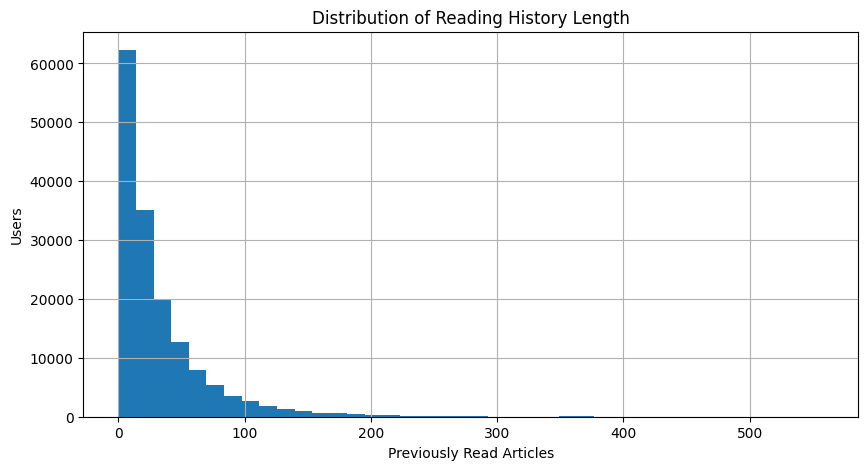

In [9]:
plt.figure(figsize=(10,5))

behaviors["history_length"].hist(bins=40)

plt.title("Distribution of Reading History Length")

plt.xlabel("Previously Read Articles")

plt.ylabel("Users")

plt.show()

Impression Length

In [10]:
behaviors["impression_length"] = (
    behaviors["impressions"]
    .str.split()
    .apply(len)
)

In [11]:
behaviors["impression_length"].describe()

count    156965.000000
mean         37.227688
std          38.594148
min           2.000000
25%          10.000000
50%          24.000000
75%          51.000000
max         299.000000
Name: impression_length, dtype: float64

Chart

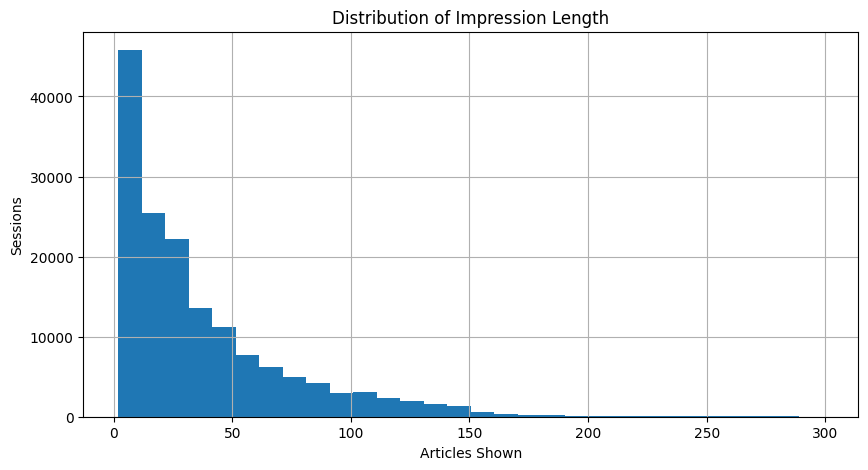

In [12]:
plt.figure(figsize=(10,5))

behaviors["impression_length"].hist(bins=30)

plt.title("Distribution of Impression Length")

plt.xlabel("Articles Shown")

plt.ylabel("Sessions")

plt.show()

Insights
   - Key findings
   - Implications for recommendation algorithms
   - Editorial Analytics
   - Articles per category

In [13]:
editorial = (
    news.groupby("category")
        .size()
        .sort_values(ascending=False)
        .reset_index(name="articles")
)

editorial

,category,articles
0,news,15774
1,sports,14510
2,finance,3107
3,foodanddrink,2551
4,lifestyle,2479
5,travel,2350
6,video,2068
7,weather,2048
8,health,1885
9,autos,1639


Coverage Percentage

In [14]:
editorial["coverage_pct"] = (
    editorial["articles"] /
    editorial["articles"].sum()
    *100
)

editorial

,category,articles,coverage_pct
0,news,15774,30.759331
1,sports,14510,28.294528
2,finance,3107,6.058656
3,foodanddrink,2551,4.974455
4,lifestyle,2479,4.834055
5,travel,2350,4.582505
6,video,2068,4.032604
7,weather,2048,3.993604
8,health,1885,3.675754
9,autos,1639,3.196053


The dataset contains over 51,000 articles across 16 categories.

The News and Sports sections account for more than half of all articles.

Reader histories vary substantially, indicating that personalization could improve content discovery.

The distribution of articles is highly imbalanced, suggesting that a popularity-based recommender may over-represent dominant categories.

Future recommendation models should balance relevance with content diversity.

Next Steps
   - Build recommendation models
   - Evaluate ranking performance